# EduPredict-XAI
## Student Performance Prediction Using Explainable AI

### Dataset Audit and Exploratory Analysis

**Research Project:** EduPredict-XAI  
**Student:** Payal Pramod Pawar  
**Program:** MCA Sem 3  
**Guide:** Mrs. Shaesta Mujawar  

### Objective

The objective of this notebook is to inspect and understand the student performance datasets before applying data preprocessing and machine learning models.

The datasets will be analyzed for:
- Dataset size
- Features and target variables
- Data types
- Missing values
- Duplicate records
- Numerical and categorical variables
- Statistical properties
- Possible data quality issues

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Check our current folder
print("Current working directory:")
print(os.getcwd())

Current working directory:
d:\MCA Sem 3\RP\EduPredict-XAI\notebooks


In [ ]:
# Find the project root
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Project Root:")
print(PROJECT_ROOT)

Project Root:
d:\MCA Sem 3\RP\EduPredict-XAI


In [ ]:
# Check the data/raw folder
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

print("Raw data folder:")
print(RAW_DATA_PATH)

print("\nFiles available:")
for file in RAW_DATA_PATH.iterdir():
    print(file.name)

Raw data folder:
d:\MCA Sem 3\RP\EduPredict-XAI\data\raw

Files available:
main_student_performance.csv
student_learning_behavior.csv
student_performance_factors.csv


In [ ]:
# Load the three datasets
main_path = RAW_DATA_PATH / "main_student_performance.csv"
factors_path = RAW_DATA_PATH / "student_performance_factors.csv"
learning_path = RAW_DATA_PATH / "student_learning_behavior.csv"

main_df = pd.read_csv(main_path)
factors_df = pd.read_csv(factors_path)
learning_df = pd.read_csv(learning_path)

print("All three datasets loaded successfully.")

All three datasets loaded successfully.


In [ ]:
# Display dataset sizes
print("MAIN DATASET")
print("Rows:", main_df.shape[0])
print("Columns:", main_df.shape[1])

print("\nSTUDENT PERFORMANCE FACTORS")
print("Rows:", factors_df.shape[0])
print("Columns:", factors_df.shape[1])

print("\nLEARNING BEHAVIOR")
print("Rows:", learning_df.shape[0])
print("Columns:", learning_df.shape[1])

MAIN DATASET
Rows: 1000
Columns: 12

STUDENT PERFORMANCE FACTORS
Rows: 6607
Columns: 20

LEARNING BEHAVIOR
Rows: 14003
Columns: 16


In [ ]:
# First 5 records
print("MAIN DATASET")
display(main_df.head())

print("STUDENT PERFORMANCE FACTORS")
display(factors_df.head())

print("LEARNING BEHAVIOR")
display(learning_df.head())

MAIN DATASET


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


STUDENT PERFORMANCE FACTORS


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


LEARNING BEHAVIOR


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [ ]:
# Last 5 records
print("MAIN DATASET")
display(main_df.tail())

MAIN DATASET


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


In [ ]:
# Column names
print("MAIN DATASET COLUMNS")
for i, column in enumerate(main_df.columns, start=1):
    print(i, "→", column)

print("\nFACTORS DATASET COLUMNS")
for i, column in enumerate(factors_df.columns, start=1):
    print(i, "→", column)

print("\nLEARNING BEHAVIOR COLUMNS")
for i, column in enumerate(learning_df.columns, start=1):
    print(i, "→", column)

MAIN DATASET COLUMNS
1 → student_id
2 → gender
3 → study_time_hours
4 → attendance_percent
5 → sleep_hours
6 → parental_education
7 → internet_access
8 → extracurricular_activities
9 → part_time_job
10 → previous_grade
11 → final_exam_score
12 → final_grade

FACTORS DATASET COLUMNS
1 → Hours_Studied
2 → Attendance
3 → Parental_Involvement
4 → Access_to_Resources
5 → Extracurricular_Activities
6 → Sleep_Hours
7 → Previous_Scores
8 → Motivation_Level
9 → Internet_Access
10 → Tutoring_Sessions
11 → Family_Income
12 → Teacher_Quality
13 → School_Type
14 → Peer_Influence
15 → Physical_Activity
16 → Learning_Disabilities
17 → Parental_Education_Level
18 → Distance_from_Home
19 → Gender
20 → Exam_Score

LEARNING BEHAVIOR COLUMNS
1 → StudyHours
2 → Attendance
3 → Resources
4 → Extracurricular
5 → Motivation
6 → Internet
7 → Gender
8 → Age
9 → LearningStyle
10 → OnlineCourses
11 → Discussions
12 → AssignmentCompletion
13 → ExamScore
14 → EduTech
15 → StressLevel
16 → FinalGrade


In [ ]:
# Data types
print("MAIN DATASET DATA TYPES")
display(main_df.dtypes)

print("\nFACTORS DATASET DATA TYPES")
display(factors_df.dtypes)

print("\nLEARNING BEHAVIOR DATA TYPES")
display(learning_df.dtypes)

MAIN DATASET DATA TYPES


student_id                      int64
gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education             object
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
final_grade                    object
dtype: object


FACTORS DATASET DATA TYPES


Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


LEARNING BEHAVIOR DATA TYPES


StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64
dtype: object

In [ ]:
# Missing values
print("MAIN DATASET - MISSING VALUES")
display(main_df.isnull().sum())

print("\nFACTORS DATASET - MISSING VALUES")
display(factors_df.isnull().sum())

print("\nLEARNING BEHAVIOR - MISSING VALUES")
display(learning_df.isnull().sum())

MAIN DATASET - MISSING VALUES


student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


FACTORS DATASET - MISSING VALUES


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


LEARNING BEHAVIOR - MISSING VALUES


StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

In [ ]:
# Missing percentage
def missing_report(df):
    missing = df.isnull().sum()
    percentage = (missing / len(df)) * 100

    report = pd.DataFrame({
        "Missing Count": missing,
        "Missing Percentage": percentage
    })

    return report.sort_values(
        by="Missing Percentage",
        ascending=False
    )

display(missing_report(main_df))

,Missing Count,Missing Percentage
parental_education,102,10.2
student_id,0,0.0
study_time_hours,0,0.0
gender,0,0.0
attendance_percent,0,0.0
sleep_hours,0,0.0
internet_access,0,0.0
extracurricular_activities,0,0.0
part_time_job,0,0.0
previous_grade,0,0.0


In [ ]:
# Duplicate records
print("Main Dataset Duplicates:", main_df.duplicated().sum())
print("Factors Dataset Duplicates:", factors_df.duplicated().sum())
print("Learning Dataset Duplicates:", learning_df.duplicated().sum())

Main Dataset Duplicates: 0
Factors Dataset Duplicates: 0
Learning Dataset Duplicates: 1534


In [ ]:
# Statistical summary
display(main_df.describe().T)
display(factors_df.describe().T)
display(learning_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
student_id,1000.0,500.5000,288.819436,1.0,250.750,500.5,750.250,1000.0
study_time_hours,1000.0,3.5707,1.478559,0.5,2.600,3.6,4.500,8.1
attendance_percent,1000.0,85.0923,9.270685,54.8,78.800,85.2,91.900,100.0
sleep_hours,1000.0,6.7995,1.203527,3.2,5.900,6.8,7.600,10.0
previous_grade,1000.0,69.7409,12.613425,31.3,61.000,69.6,78.400,100.0
final_exam_score,1000.0,83.5435,10.341333,46.8,76.075,83.8,91.525,100.0


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


,count,mean,std,min,25%,50%,75%,max
StudyHours,14003.0,19.987431,5.890637,5.0,16.0,20.0,24.0,44.0
Attendance,14003.0,80.194316,11.472181,60.0,70.0,80.0,90.0,100.0
Resources,14003.0,1.104406,0.697362,0.0,1.0,1.0,2.0,2.0
Extracurricular,14003.0,0.594158,0.491072,0.0,0.0,1.0,1.0,1.0
Motivation,14003.0,0.905806,0.695896,0.0,0.0,1.0,1.0,2.0
Internet,14003.0,0.925516,0.262566,0.0,1.0,1.0,1.0,1.0
Gender,14003.0,0.551953,0.497311,0.0,0.0,1.0,1.0,1.0
Age,14003.0,23.532172,3.514293,18.0,20.0,24.0,27.0,29.0
LearningStyle,14003.0,1.515461,1.112941,0.0,1.0,2.0,3.0,3.0
OnlineCourses,14003.0,9.891952,6.112801,0.0,5.0,10.0,15.0,20.0


In [ ]:
# Numerical vs categorical columns
numeric_columns = main_df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = main_df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']

Categorical Columns:
['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']


In [ ]:
# Unique values
for column in categorical_columns:
    print("=" * 60)
    print(column)
    print(main_df[column].unique())

gender
['Male' 'Female']
parental_education
['Bachelors' 'High School' nan 'Masters' 'PhD']
internet_access
['Yes' 'No']
extracurricular_activities
['Yes' 'No']
part_time_job
['No' 'Yes']
final_grade
['A' 'B' 'D' 'C' 'F']


In [ ]:
# Target variable investigation
TARGET = "final_exam_score"

print("Target variable:", TARGET)
print("\nTarget data type:")
print(main_df[TARGET].dtype)

print("\nTarget statistics:")
display(main_df[TARGET].describe())

Target variable: final_exam_score

Target data type:
float64

Target statistics:


count    1000.000000
mean       83.543500
std        10.341333
min        46.800000
25%        76.075000
50%        83.800000
75%        91.525000
max       100.000000
Name: final_exam_score, dtype: float64

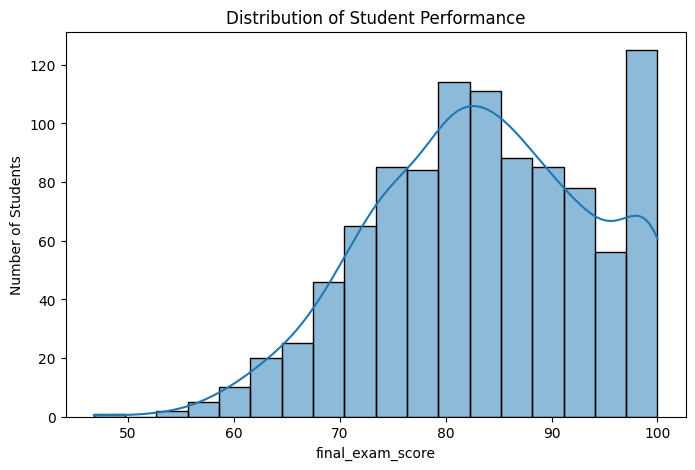

In [ ]:
# Target distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=main_df,
    x=TARGET,
    kde=True
)

plt.title("Distribution of Student Performance")
plt.xlabel(TARGET)
plt.ylabel("Number of Students")

plt.show()

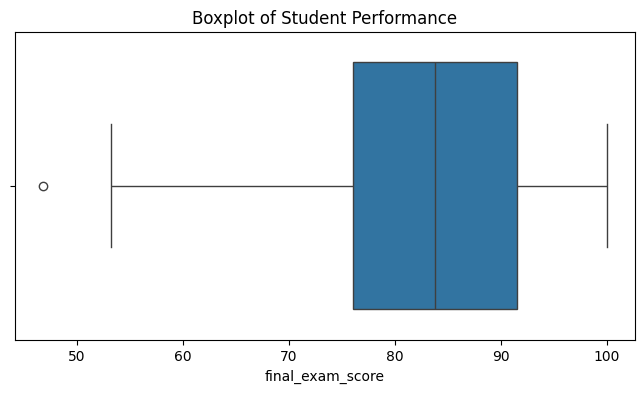

In [ ]:
# Boxplot
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=main_df[TARGET]
)
plt.title("Boxplot of Student Performance")
plt.show()

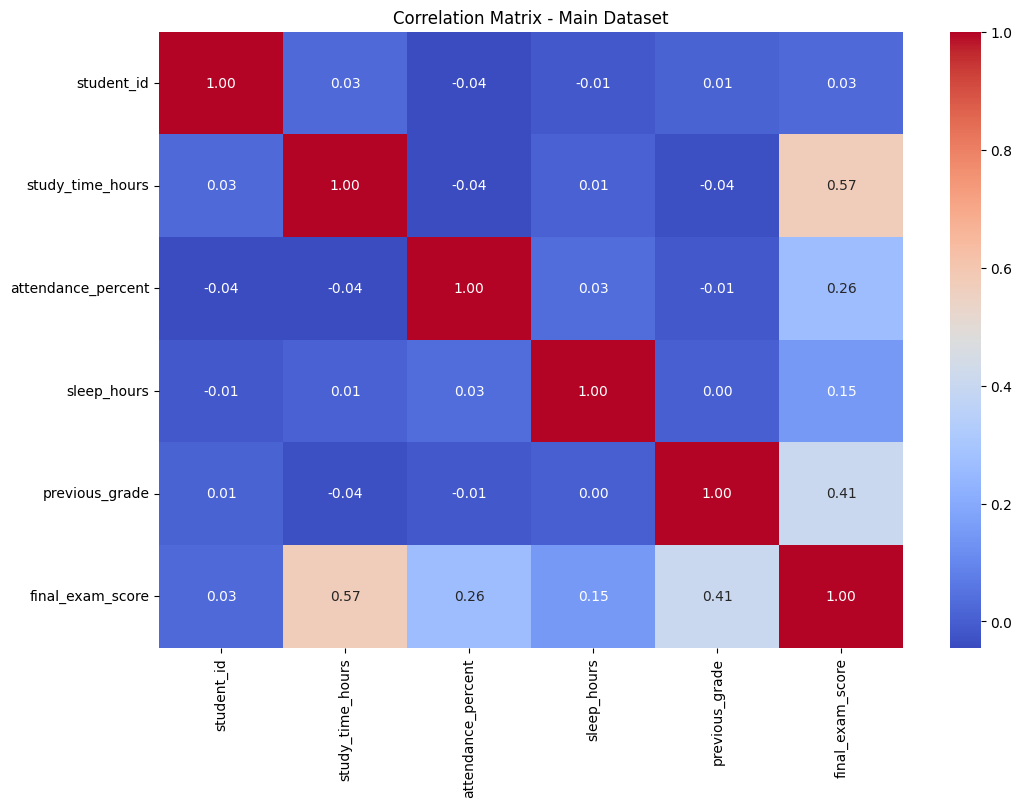

In [ ]:
# Correlation analysis
correlation = main_df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Main Dataset")
plt.show()

In [ ]:
# Features most correlated with target
target_correlations = correlation[TARGET].sort_values(
    ascending=False
)

print("Correlation with target:")
display(target_correlations)

Correlation with target:


final_exam_score      1.000000
study_time_hours      0.567513
previous_grade        0.406327
attendance_percent    0.261872
sleep_hours           0.147811
student_id            0.025282
Name: final_exam_score, dtype: float64

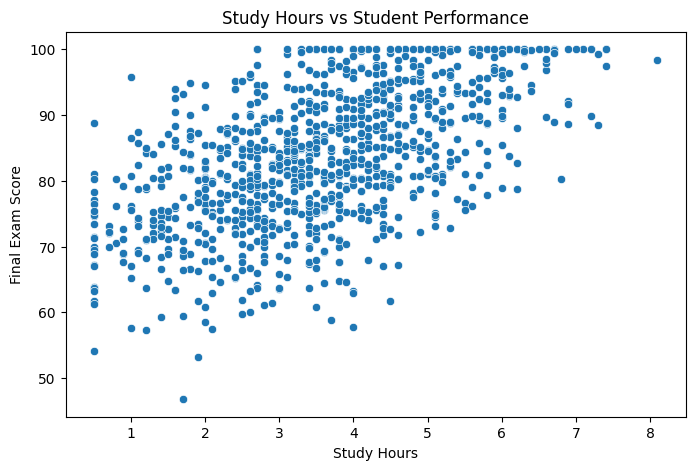

In [ ]:
# Feature relationship plots
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=main_df,
    x="study_time_hours",
    y=TARGET
)

plt.title("Study Hours vs Student Performance")
plt.xlabel("Study Hours")
plt.ylabel("Final Exam Score")

plt.show()